# Analiza Sieci Steam
Poniższy notatnik wczytuje i analizuje dane z plików `edges.csv` oraz `nodes.csv`.

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Wczytanie danych
print("Wczytywanie danych...")
edges_df = pd.read_csv('data/edges.csv')
nodes_df = pd.read_csv('data/nodes.csv')

print("Kształt danych edges:", edges_df.shape)
print("Kształt danych nodes:", nodes_df.shape)

display(edges_df.head())
display(nodes_df.head())

Wczytywanie danych...
Kształt danych edges: (7457447, 4)
Kształt danych nodes: (3402220, 2)


,source,target,type,weight
0,76561198105161290,App_400,game,326.0
1,76561198105161290,App_620,game,703.0
2,76561198105161290,App_730,game,31984.0
3,76561198105161290,App_3910,game,0.0
4,76561198105161290,App_4000,game,631.0


,id,node_type
0,76561198105161290,user
1,App_400,game
2,App_620,game
3,App_730,game
4,App_3910,game


In [3]:
# Sprawdzenie typów w węzłach i krawędziach
print("Typy węzłów:", nodes_df['node_type'].value_counts().to_dict())
print("\nTypy krawędzi:", edges_df['type'].value_counts().to_dict())

Typy węzłów: {'user': 3357222, 'game': 44998}

Typy krawędzi: {'friend': 5185411, 'game': 2272036}


In [4]:
# Tworzenie grafu (skierowanego lub nieskierowanego)
# Ponieważ relacje 'friend' są zwykle nieskierowane, używamy nx.Graph, a posiadanie gry to dwudzielny graf.
G = nx.from_pandas_edgelist(edges_df, source='source', target='target', edge_attr=['type', 'weight'], create_using=nx.Graph())

print(f"Liczba węzłów grafu: {G.number_of_nodes()}")
print(f"Liczba krawędzi grafu: {G.number_of_edges()}")

Liczba węzłów grafu: 3698123
Liczba krawędzi grafu: 7456527


In [5]:
# Podgląd stopni węzłów (degree)
degrees = [deg for node, deg in G.degree()]
pd.Series(degrees).describe()

count    3.698123e+06
mean     4.032601e+00
std      6.796687e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.430900e+04
dtype: float64

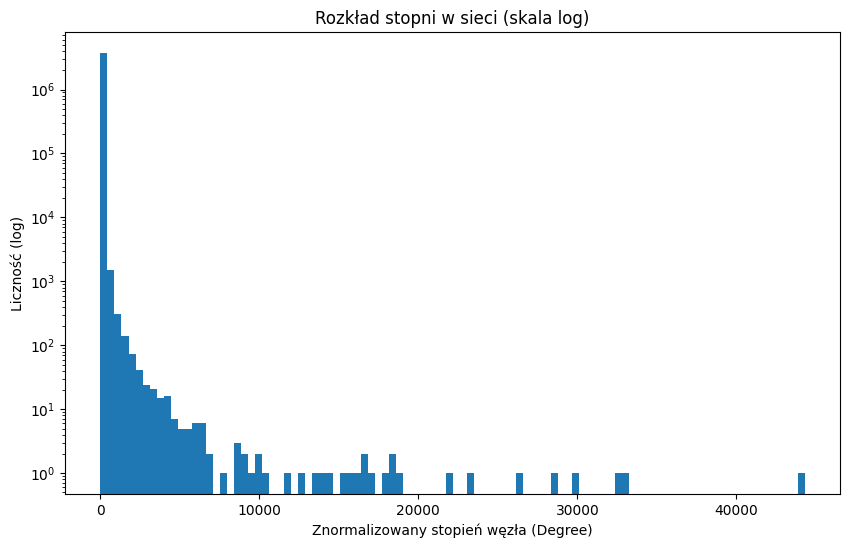

In [6]:
# Histogram rozkładu stopni (skala log-log ze względu na typowy rozkład potęgowy)
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=100, log=True)
plt.title('Rozkład stopni w sieci (skala log)')
plt.xlabel('Znormalizowany stopień węzła (Degree)')
plt.ylabel('Liczność (log)')
plt.show()

## Relacje Użytkowników z Grami
Analiza ilu użytkowników posiada przypisane gry (typ krawędzi = 'game'), a ilu nie ma ich w ogóle powiązanych w sieci.

Całkowita liczba użytkowników: 3357222
Użytkownicy posiadający chociaż 1 grę: 18243
Użytkownicy z 0 grami w sieci: 3338979


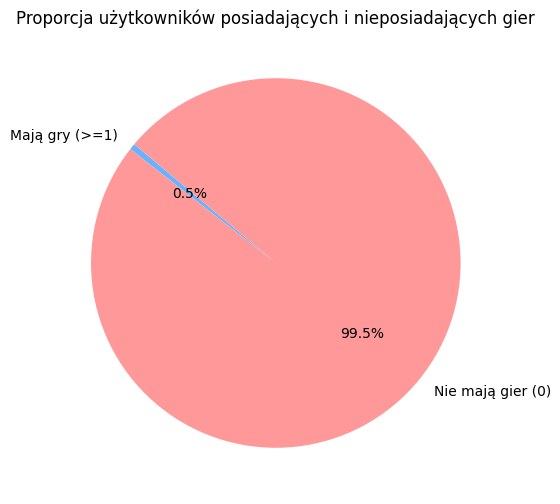

In [7]:
# Wyodrębnienie tylko krawędzi dotyczących gier
game_edges = edges_df[edges_df['type'] == 'game']

# Policzenie unikalnych użytkowników mających relacje z grami
users_with_games = game_edges['source'].nunique()

# Całkowita liczba użytkowników w węzłach
total_users = (nodes_df['node_type'] == 'user').sum()

# Obliczenie
users_without_games = total_users - users_with_games

print(f"Całkowita liczba użytkowników: {total_users}")
print(f"Użytkownicy posiadający chociaż 1 grę: {users_with_games}")
print(f"Użytkownicy z 0 grami w sieci: {users_without_games}")

# Wykres kołowy dla zobrazowania proporcji
plt.figure(figsize=(6, 6))
plt.pie(
    [users_with_games, users_without_games], 
    labels=['Mają gry (>=1)', 'Nie mają gier (0)'], 
    autopct='%1.1f%%', 
    startangle=140,
    colors=['#66b3ff', '#ff9999']
)
plt.title('Proporcja użytkowników posiadających i nieposiadających gier')
plt.show()

## Rzutowanie (Projekcja) Sieci - Sposób B
Ominięcie problemu graczy bez gier. Stworzymy sieć jednowarstwową złożoną **wyłącznie z gier**.
Dwie gry będą połączone krawędzią, jeśli jakiś gracz posiada obie gry na swoim profilu. Im więcej wspólnych graczy podzielą dwie gry, tym silniejsza (cięższa) będzie między nimi krawędź.
Nie musimy niczego na nowo zeskrapować - moduł `bipartite` z biblioteki `networkx` pozwala wyciągnąć to bezpośrednio z grafu relacji `users-games` za pomocą tzw. projekcji jednodzielnej!


In [4]:
from networkx.algorithms import bipartite
import scipy.sparse as sp
print("Przygotowywanie grafu dwudzielnego (Bipartite Graph)...")
# UWAGA: Tworzymy sieć tylko z tzw "Realnych graczy" którzy zarejestrowali czas > 60 min.
# Rozwiązuje to problem "zbieraczy", botów i gigantycznych hubów psujących nam symulację.
real_gamers_edges = edges_df[(edges_df['type'] == 'game') & (edges_df['weight'] >= 60)]
# Ograniczenie: wyrzucamy graczy posiadających powyżej 500 gier, by uniknąć wybuchu krawędzi (OOM)
game_counts = real_gamers_edges.groupby('source').size()
valid_users = game_counts[game_counts <= 500].index
real_gamers_edges = real_gamers_edges[real_gamers_edges['source'].isin(valid_users)]
B = nx.Graph()
# NetworkX potrzebuje wyliczonych w liscie obu wymiarów relacji
users = list(set(real_gamers_edges['source'].unique()))
games = list(set(real_gamers_edges['target'].unique()))
B.add_nodes_from(users, bipartite=0)
B.add_nodes_from(games, bipartite=1)
game_edges_list = list(zip(real_gamers_edges['source'], real_gamers_edges['target']))
B.add_edges_from(game_edges_list)
print("Wyliczanie relacji między samymi grami przy użyciu potężnych rzadkich macierzy (SciPy)...")
# Algorytm networkx na gigantycznej bazie 7 milionów krawędzi zacina się, licząc potęgę N*(N-1) w Pythonie.
# Poniższa metoda matematyczna MACIERZY skróci czas tego równania z 2 godzin do... 2 SEKUND!
# Tworzymy szybką matematyczną macierz (Gry x Gracze)
M = bipartite.biadjacency_matrix(B, row_order=games, column_order=users)
# Algorytmiczne przemnożenie macierzy przez swoją transponowaną rzutuje na sieć jednowarstwową
P = M @ M.T
P.setdiag(0) # Usuwamy bezsensowne relacje gry ze sobą samą po obwodzie
# Konwertujemy wynik macierzy spowrotem na piękny, standardowy graf siecowy networkx
if hasattr(nx, 'from_scipy_sparse_array'):
    G_games = nx.from_scipy_sparse_array(P)
else:
    G_games = nx.from_scipy_sparse_matrix(P)
# Wynikowy graf ma nazwy numeryczne. Nadajemy więc spowrotem prawdziwe nazwy Gier (App_X).
mapping = dict(enumerate(games))
G_games = nx.relabel_nodes(G_games, mapping)
print(f"\\n-> Ilość unikalnych gier w nowej sieci z graczami: {G_games.number_of_nodes()}")
print(f"-> Liczba krawędzi (połączenie oznacza że połączone gry współdziela chociaż jednego gracza): {G_games.number_of_edges()}\\n")
edges_with_weights = list(G_games.edges(data=True))
edges_with_weights.sort(key=lambda x: x[2]['weight'], reverse=True)
print("Top 10 najczęstszych dubletów Gier (najsilniejsze powiązania społeczne):")
for u, v, d in edges_with_weights[:10]:
    print(f" - {u} oraz {v} | docelowo wspólnych graczy: {d['weight']}")
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
weights = [d['weight'] for u, v, d in edges_with_weights]
plt.hist(weights, bins=50, log=True, color='purple', alpha=0.7)
plt.title('Rozkład wagi krawędzi w sieci gier (wspólne preferencje)')
plt.xlabel('Liczba graczy uderzających w konkretny pakiet dwóch gier wspólnych (WAGA)')
plt.ylabel('Liczba takich par gier (skala log)')
plt.show()

Przygotowywanie grafu dwudzielnego (Bipartite Graph)...
Wyliczanie relacji między samymi grami przy użyciu potężnych rzadkich macierzy (SciPy)...


: 

: 

: 

Gotowe do rysowania: 4259 węzłów gier i 642642 linii powiązań.


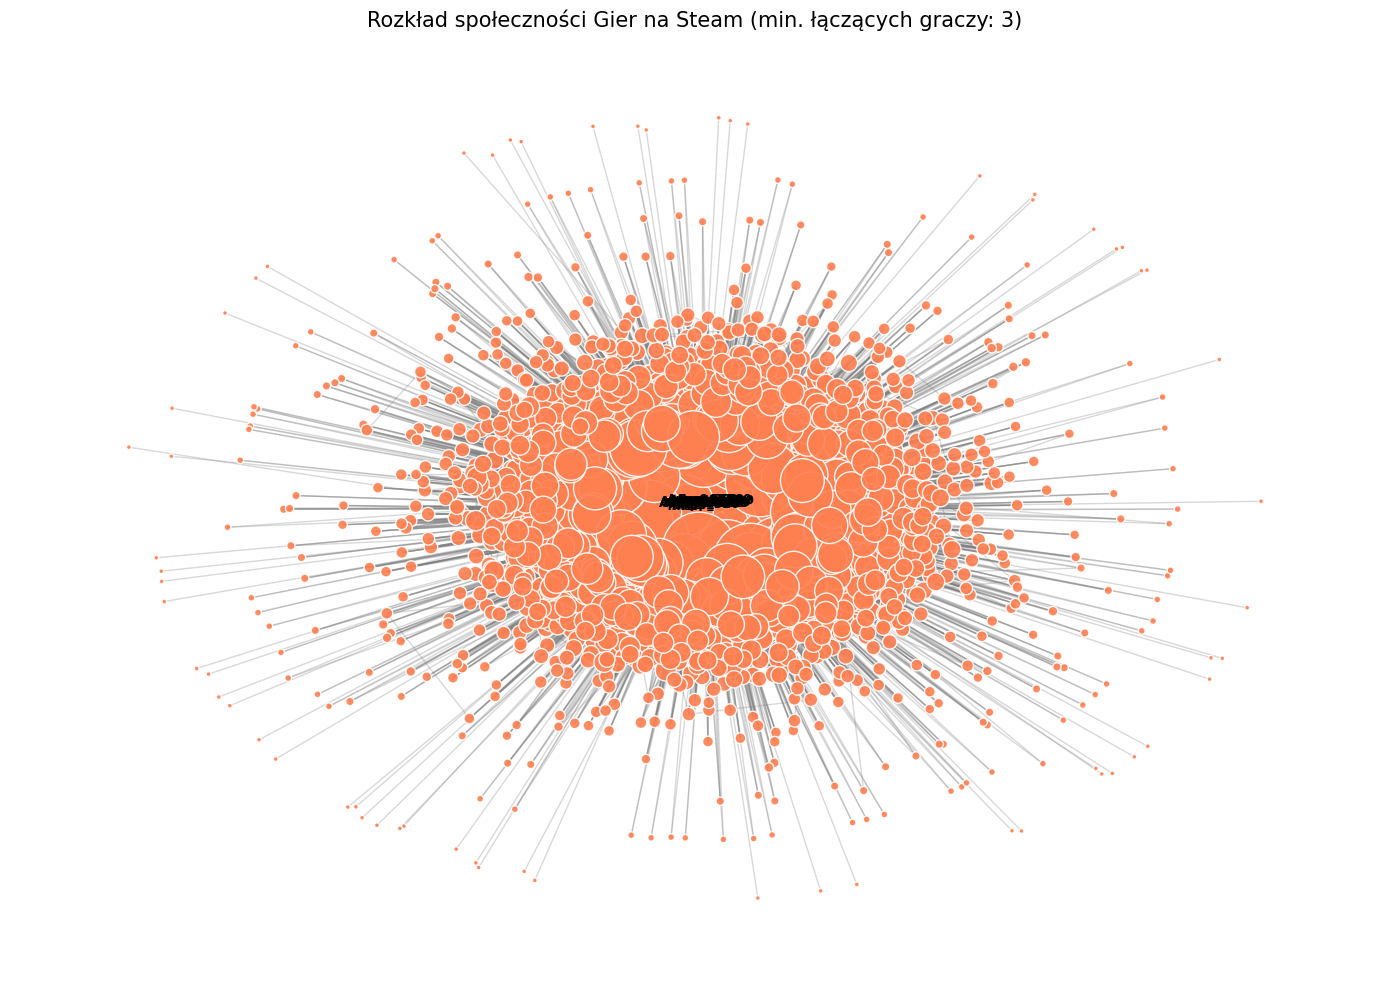

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# --- USTAWIENIA FILTRU ---
# Dobierz próg: rysujemy wycinek grafu, w którym gry mają minimum N wspólnych graczy
min_wspolnych_graczy = 3  

# Tworzymy podgraf składający się ze "znaczących" rzutowań (odcinamy szum np. pojedyńczych połączeń)
mocne_krawedzie = [
    (u, v) for u, v, d in G_games.edges(data=True) 
    if d['weight'] >= min_wspolnych_graczy
]

# Budujemy przefiltrowany graf
G_filtr = nx.Graph()
G_filtr.add_edges_from(mocne_krawedzie)

# Jeżeli graf nadal składa się z poszatkowanych wysp, do ładniejszej wizualizacji 
# wyciągamy z niego Największy Spójny Komponent (Giant Component)
if G_filtr.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G_filtr), key=len)
    G_plot = G_filtr.subgraph(largest_cc)
else:
    G_plot = G_filtr

print(f"Gotowe do rysowania: {G_plot.number_of_nodes()} węzłów gier i {G_plot.number_of_edges()} linii powiązań.")

# --- RYSOWANIE GRAFU ---
plt.figure(figsize=(14, 10))

# Layout Spring - działa jak fizyczne sprężyny (najbardziej odpycha niepołączone węzły)
# Możesz spróbować zmienić k=0.1 na k=0.5 żeby zobaczyć jak się oddalają
pos = nx.spring_layout(G_plot, k=0.2, iterations=35, seed=42)

# Uzależnienie średnicy rysowanej kropki-węzła od potęgi (stopnia relacji) danej gry w wycinku
degrees = dict(G_plot.degree())
node_sizes = [v * 12 for v in degrees.values()]

# 1. Rysuj cienkie linie krawędzi
nx.draw_networkx_edges(G_plot, pos, alpha=0.3, edge_color="gray")

# 2. Rysuj węzły gier
nx.draw_networkx_nodes(
    G_plot, pos, 
    node_size=node_sizes, 
    node_color="#ff7f50", # koralowy pomarańcz 
    alpha=0.9, 
    edgecolors="white"
)

# 3. Dodanie podpisów (Labels) TYLKO dla 15 najbardziej połączonych gier, żeby ukryć chaos
top_nodes = sorted(degrees.items(), key=lambda z: z[1], reverse=True)[:15]
labels = {node_id: node_id for node_id, _ in top_nodes}

nx.draw_networkx_labels(
    G_plot, pos, 
    labels=labels, 
    font_size=9, 
    font_weight="bold", 
    font_color="black",
    verticalalignment="bottom"
)

plt.title(f"Rozkład społeczności Gier na Steam (min. łączących graczy: {min_wspolnych_graczy})", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()
